In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import nbformat as nbf
import os


In [2]:
df=pd.read_csv('StudentsPerformance.csv')

In [3]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [5]:
df.isnull().values.any()

False

In [7]:
df.shape

(1000, 8)

In [21]:
features_with_na=[features for features in df.columns if df[features].isnull().sum()>1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean(), 4),  ' % missing values')


In [23]:
print(features_with_na)

[]


In [24]:
# list of numerical variables
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O']

print('Number of numerical variables: ', len(numerical_features))

# visualise the numerical variables
df[numerical_features].head()

Number of numerical variables:  3


,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [25]:
# list of variables that contain year information
year_feature = [feature for feature in numerical_features if 'Yr' in feature or 'Year' in feature]

year_feature

[]

In [27]:
print("\n--- Data info ---")
buffer_info = df.info()
print("\n--- Data description ---")
display(df.describe(include='all'))

print("\n--- Null values per column ---")
print(df.isnull().sum())


--- Data info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

--- Data description ---


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000



--- Null values per column ---
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [28]:
print("\nColumns:", df.columns.tolist())


Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [29]:
# Attempt to find numeric columns for modeling
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numeric columns detected:", numeric_cols)

Numeric columns detected: ['math score', 'reading score', 'writing score']


In [30]:
# If numeric_cols contains exactly two columns, assume first is Hours (feature) and second is Score (target).
if len(numeric_cols) >= 2:
    feature_col = numeric_cols[0]
    target_col = numeric_cols[1]
else:
    # fallback: try common names
    possible_features = ['Hours', 'Hours studied', 'StudyHours', 'Studied Hours', 'Time']
    possible_targets = ['Scores', 'Score', 'Marks', 'Percentage', 'Result']
    feature_col = None
    target_col = None
    for c in df.columns:
        if c in possible_features and feature_col is None:
            feature_col = c
        if c in possible_targets and target_col is None:
            target_col = c
    if feature_col is None or target_col is None:
        # last resort: pick first two columns
        cols = df.columns.tolist()
        feature_col, target_col = cols[0], cols[1]

In [31]:
print(f"\nUsing feature = '{feature_col}', target = '{target_col}' for modeling.")

X = df[[feature_col]].values.reshape(-1, 1)
y = df[target_col].values.reshape(-1, 1)


Using feature = 'math score', target = 'reading score' for modeling.


Text(0, 0.5, 'reading score')

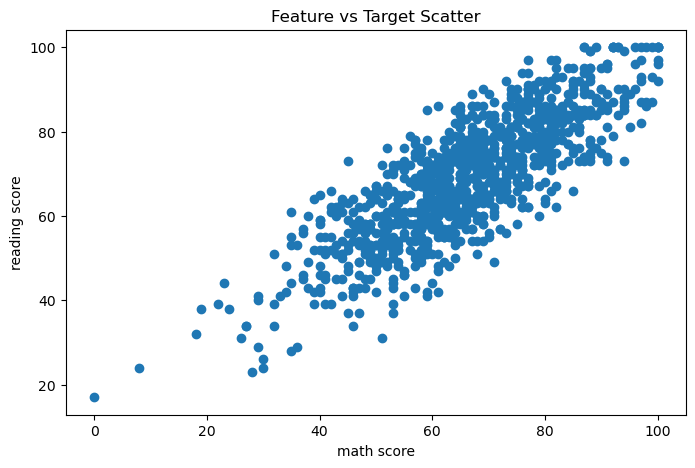

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.title("Feature vs Target Scatter")
plt.xlabel(feature_col)
plt.ylabel(target_col)

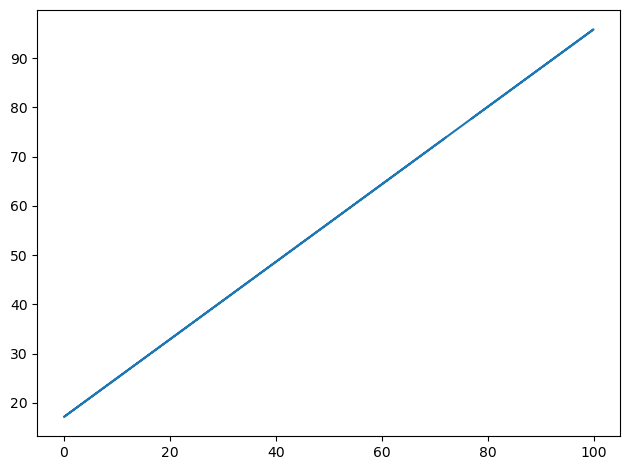

In [33]:
lr_viz = LinearRegression()
lr_viz.fit(X, y)
y_line = lr_viz.predict(X)
plt.plot(X, y_line)
plt.tight_layout()
plt.show()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
cv_scores = cross_val_score(model, X, y.ravel(), cv=5, scoring='r2')

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [36]:
print("\n--- Model evaluation ---")
print(f"Coefficient (slope): {model.coef_[0][0]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")
print(f"RMSE on test set: {rmse:.4f}")
print(f"R^2 on test set: {r2:.4f}")
print(f"5-fold CV R^2 scores: {cv_scores}")
print(f"5-fold CV R^2 mean: {cv_scores.mean():.4f}")



--- Model evaluation ---
Coefficient (slope): 0.7843
Intercept: 17.4020
RMSE on test set: 8.5020
R^2 on test set: 0.6806
5-fold CV R^2 scores: [0.73156244 0.64682574 0.62062867 0.65712708 0.66007717]
5-fold CV R^2 mean: 0.6632


In [39]:
# Example prediction: predict for 9.25 hours if the feature is indeed hours (common in tutorial)
example_hours = 9.25
try:
    example_pred = model.predict([[example_hours]])[0][0]
    print(f"\nExample prediction: For {example_hours} {feature_col}, predicted {target_col} = {example_pred:.2f}")
except Exception:
    pass


Example prediction: For 9.25 math score, predicted reading score = 24.66
